In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
churn_df_km = pd.read_csv('churn-bigml-80.csv')

--- Running the Elbow Method ---


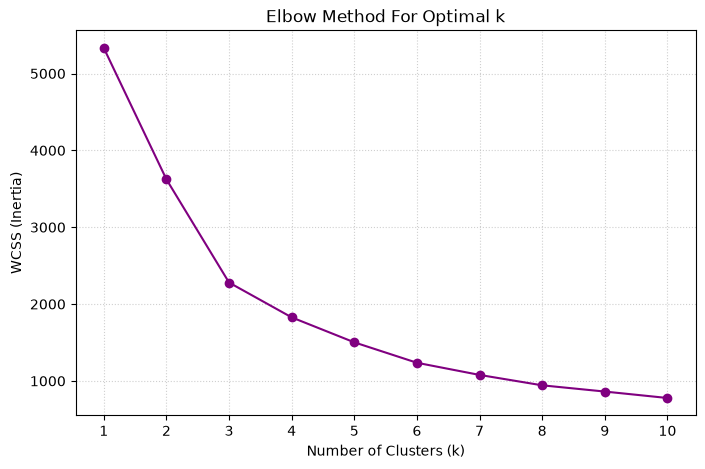

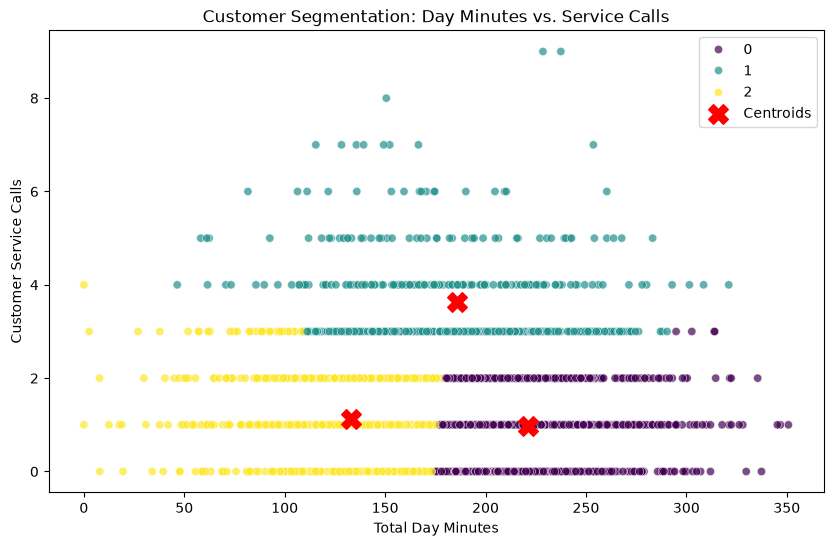

In [4]:
X_cluster = churn_df_km[['Total day minutes', 'Customer service calls']]

scaler_km = StandardScaler()
X_scaled = scaler_km.fit_transform(X_cluster)

wcss = [] # Within-Cluster Sum of Squares (Inertia)
k_range = range(1, 11)

print("--- Running the Elbow Method ---")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='-', color='purple')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)


X_cluster = X_cluster.copy()
X_cluster['Cluster'] = clusters


plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=X_cluster, 
    x='Total day minutes', 
    y='Customer service calls', 
    hue='Cluster', 
    palette='viridis', 
    alpha=0.7
)


centers_unscaled = scaler_km.inverse_transform(kmeans_final.cluster_centers_)
plt.scatter(centers_unscaled[:, 0], centers_unscaled[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.title('Customer Segmentation: Day Minutes vs. Service Calls')
plt.xlabel('Total Day Minutes')
plt.ylabel('Customer Service Calls')
plt.legend()
plt.show()